# HopeEXP — Task D: Outcome Stance & Actor
**Modelo base:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación de fragmentos (Spans). Hay dos subtareas:
1. **Outcome Stance**: Avoided, Desired
2. **Actor**: Self, Other, World/System, Unclear

**Nota**: Cada muestra de entrenamiento es un fragmento (span), no el texto completo del post.

## 0. Setup e Imports

In [1]:
%pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached sentencepiece-0.2.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached huggingface_hub-1.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached regex-2026.2.28-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-

In [2]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath("."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    compute_class_weights,
)
from src.dataset import build_all_dataloaders
from src.model import (
    build_model, build_tokenizer, count_parameters,
    CANDIDATE_MODELS, list_candidate_models,
)
from src.trainer import train, compare_models

print("Imports correctos")

Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA H200 NVL


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
TRAIN_PATH = "./HopeEXP_Train.jsonl"
DEV_SIZE   = 0.20

# ── Columnas del dataset ──────────────────────────────────────
TEXT_COL    = "span"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
MAX_LENGTH  = 512
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 16
COMPARISON_EPOCHS = 3
NUM_EPOCHS  = 25
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5
USE_POS_WEIGHT = True

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs/task_d_roles_notebook"
COMPARISON_DIR = os.path.join(OUTPUT_DIR, "model_comparison")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Extraer spans de los datos
def load_task_d_data(filepath):
    all_data = pd.read_json(path_or_buf=filepath, lines=True)
    
    spans = []
    stances = []
    actors = []
    
    for _, row in all_data.iterrows():
        annotations = row.get("span_annotations", [])
        if isinstance(annotations, list):
            for ann in annotations:
                spans.append(ann["span"])
                stances.append(ann["outcome_stance"])
                
                actor = ann["actor"]
                if actor == "World/System":
                    actor = "World"
                actors.append(actor)
                
    df = pd.DataFrame({
        "span": spans,
        "outcome_stance": stances,
        "actor": actors
    })
    return df

full_train_df = load_task_d_data(TRAIN_PATH)

STANCE_LABELS = ["Avoided", "Desired"]
ACTOR_LABELS = ["Self", "Other", "World", "Unclear"]

# Convertir a listas para usar compute_class_weights
full_train_df["stance_list"] = full_train_df["outcome_stance"].apply(lambda x: [x])
full_train_df["actor_list"] = full_train_df["actor"].apply(lambda x: [x])

# Para el split, estratificamos por una combinación de stance y actor
full_train_df["stratify_col"] = full_train_df["outcome_stance"] + "_" + full_train_df["actor"]

# Limpiar clases con muy pocos ejemplos para stratify
stratify_counts = full_train_df["stratify_col"].value_counts()
valid_stratify = stratify_counts[stratify_counts > 1].index
full_train_df.loc[~full_train_df["stratify_col"].isin(valid_stratify), "stratify_col"] = "Other_Unclear" # Fallback

train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["stratify_col"],
)

train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Spans totales: {len(full_train_df)}")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})\n")

display(train_df.head(3))

Spans totales: 3756
  → Train: 3004 | Dev: 752  (split 80/20)



,span,outcome_stance,actor,stance_list,actor_list,stratify_col
0,I'm absolutely certain that removing all perso...,Desired,World,[Desired],[World],Desired_World
1,"Yeah, I'm sure the immigration office will jus...",Desired,Other,[Desired],[Other],Desired_Other
2,"If I can be honest with her about my anxiety, ...",Desired,Self,[Desired],[Self],Desired_Self


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de span limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de span limpio:
I'm absolutely certain that removing all personal autonomy will be the breakthrough I've needed


In [7]:
# ── Codificación a vectores binarios ──────────────────────────
def encode_label(label: str, label_set: list) -> list:
    vector = [0] * len(label_set)
    if label in label_set:
        vector[label_set.index(label)] = 1
    return vector

train_df["stance_vec"] = train_df["outcome_stance"].apply(lambda x: encode_label(x, STANCE_LABELS))
dev_df["stance_vec"]   = dev_df["outcome_stance"].apply(lambda x: encode_label(x, STANCE_LABELS))

train_df["actor_vec"] = train_df["actor"].apply(lambda x: encode_label(x, ACTOR_LABELS))
dev_df["actor_vec"]   = dev_df["actor"].apply(lambda x: encode_label(x, ACTOR_LABELS))

train_texts = train_df[TEXT_COL].tolist()
dev_texts   = dev_df[TEXT_COL].tolist()

train_stance_labels = train_df["stance_vec"].tolist()
dev_stance_labels   = dev_df["stance_vec"].tolist()

train_actor_labels = train_df["actor_vec"].tolist()
dev_actor_labels   = dev_df["actor_vec"].tolist()

print("Ejemplo Stance Vector:", train_stance_labels[0])
print("Ejemplo Actor Vector:", train_actor_labels[0])

Ejemplo Stance Vector: [0, 1]
Ejemplo Actor Vector: [0, 0, 1, 0]


## 3. Análisis de Desbalanceo y Pesos

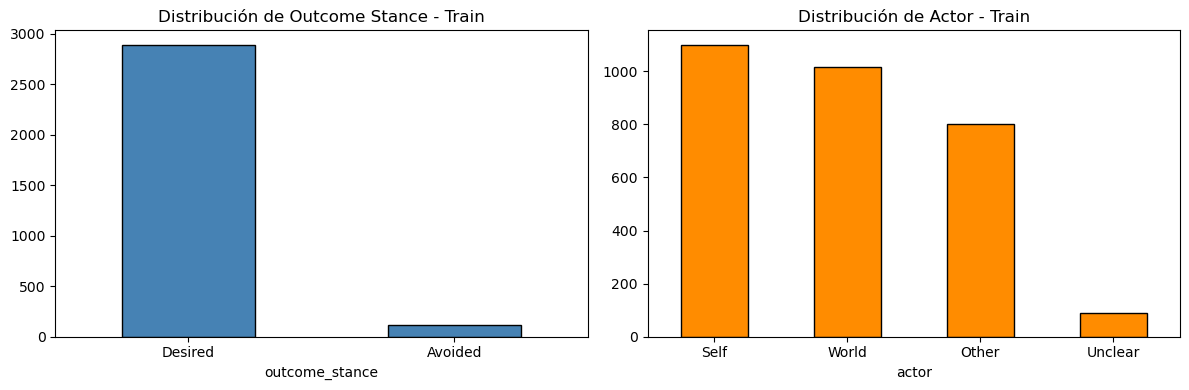

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['outcome_stance'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Outcome Stance - Train')
axes[0].tick_params(axis='x', rotation=0)

train_df['actor'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Distribución de Actor - Train')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task_d_distribution.png"), dpi=150)
plt.show()

In [9]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_stance_np = compute_class_weights(train_df, emotions_col="stance_list", labels=STANCE_LABELS)
pos_weight_stance = torch.tensor(pos_weights_stance_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase (Stance):")
for label, w in zip(STANCE_LABELS, pos_weights_stance_np):
    print(f"  {label:12s}: {w:.2f}")
    
pos_weights_actor_np = compute_class_weights(train_df, emotions_col="actor_list", labels=ACTOR_LABELS)
pos_weight_actor = torch.tensor(pos_weights_actor_np) if USE_POS_WEIGHT else None

print("\nPesos positivos por clase (Actor):")
for label, w in zip(ACTOR_LABELS, pos_weights_actor_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase (Stance):
  Avoided     : 24.90
  Desired     : 0.04

Pesos positivos por clase (Actor):
  Self        : 1.73
  Other       : 2.76
  World       : 1.96
  Unclear     : 32.75


## 4. Tokenizador y DataLoaders

In [10]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes de los spans
sample_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in train_texts[:500]]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 21.5
Percentil 95: 49
Máximo: 91
MAX_LENGTH configurado: 512


In [11]:
# Loaders para Stance
loaders_stance = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_stance_labels,
    dev_texts=dev_texts,
    dev_labels=dev_stance_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

# Loaders para Actor
loaders_actor = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_actor_labels,
    dev_texts=dev_texts,
    dev_labels=dev_actor_labels,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders_stance['train'])} | Dev: {len(loaders_stance['dev'])}")

Batches — Train: 188 | Dev: 47


## 5. Comparación de Modelos

In [12]:
list_candidate_models(multilingual_only=True)
candidate_names = [m["name"] for m in CANDIDATE_MODELS if m["multilingual"]]

Modelo                                        Multilingüe    Descripción
----------------------------------------------------------------------------------------------------
microsoft/mdeberta-v3-base                    ✓              mDeBERTa v3 – fuerte en tareas multilingüe, mejor baseline general
xlm-roberta-base                              ✓              XLM-RoBERTa base – robusto, ampliamente usado en NLP multilingüe
xlm-roberta-large                             ✓              XLM-RoBERTa large – mayor capacidad, requiere más VRAM
bert-base-multilingual-cased                  ✓              mBERT cased – baseline clásico multilingüe


In [13]:
print("====== COMPARACIÓN PARA OUTCOME STANCE ======")
comparison_results_stance = compare_models(
    model_names=candidate_names,
    train_loader=loaders_stance["train"],
    dev_loader=loaders_stance["dev"],
    device=DEVICE,
    num_labels=len(STANCE_LABELS),
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_stance,
    save_dir=os.path.join(COMPARISON_DIR, "stance"),
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

BEST_ARCH_STANCE = comparison_results_stance.iloc[0]["model"]
print(f"\nMejor arquitectura Stance: {BEST_ARCH_STANCE}")

====== COMPARACIÓN PARA OUTCOME STANCE ======

  Evaluando: microsoft/mdeberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [42.3s]
- Train Loss: 1.9142  |  Dev Loss: 2.2590
- Dev f1_macro: 0.4902
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4902)

Época 2/3  [41.8s]
- Train Loss: 1.6927  |  Dev Loss: 1.9225
- Dev f1_macro: 0.6440
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6440)

Época 3/3  [41.8s]
- Train Loss: 1.4220  |  Dev Loss: 1.6333
- Dev f1_macro: 0.6651
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6651)

- Entrenamiento finalizado. Mejor f1_macro: 0.6651

  Evaluando: xlm-roberta-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [87.4s]
- Train Loss: 2.6616  |  Dev Loss: 3.9852
- Dev f1_macro: 0.4902
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4902)

Época 2/3  [87.2s]
- Train Loss: 2.8028  |  Dev Loss: 2.4427
- Dev f1_macro: 0.4902
Sin mejora (1/2)

Época 3/3  [87.2s]
- Train Loss: 2.3120  |  Dev Loss: 2.7460
- Dev f1_macro: 0.4902
Sin mejora (2/2)

- Early stopping activado en época 3
- Entrenamiento finalizado. Mejor f1_macro: 0.4902

  Evaluando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [29.0s]
- Train Loss: 1.2089  |  Dev Loss: 1.7661
- Dev f1_macro: 0.7757
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7757)

Época 2/3  [29.0s]
- Train Loss: 0.7276  |  Dev Loss: 1.0869
- Dev f1_macro: 0.7963
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7963)

Época 3/3  [29.1s]
- Train Loss: 0.3617  |  Dev Loss: 1.1332
- Dev f1_macro: 0.8018
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/stance/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.8018)

- Entrenamiento finalizado. Mejor f1_macro: 0.8018

  Ranking final de modelos
                       model  f1_macro  best_epoch  train_lo

In [14]:
print("\n====== COMPARACIÓN PARA ACTOR ======")
comparison_results_actor = compare_models(
    model_names=candidate_names,
    train_loader=loaders_actor["train"],
    dev_loader=loaders_actor["dev"],
    device=DEVICE,
    num_labels=len(ACTOR_LABELS),
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_actor,
    save_dir=os.path.join(COMPARISON_DIR, "actor"),
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

BEST_ARCH_ACTOR = comparison_results_actor.iloc[0]["model"]
print(f"\nMejor arquitectura Actor: {BEST_ARCH_ACTOR}")


====== COMPARACIÓN PARA ACTOR ======

  Evaluando: microsoft/mdeberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [41.8s]
- Train Loss: 1.1840  |  Dev Loss: 1.0480
- Dev f1_macro: 0.4271
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4271)

Época 2/3  [41.8s]
- Train Loss: 1.0552  |  Dev Loss: 1.1041
- Dev f1_macro: 0.4040
Sin mejora (1/2)

Época 3/3  [41.8s]
- Train Loss: 0.9418  |  Dev Loss: 1.0944
- Dev f1_macro: 0.4373
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4373)

- Entrenamiento finalizado. Mejor f1_macro: 0.4373

  Evaluando: xlm-roberta-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [87.3s]
- Train Loss: 1.3122  |  Dev Loss: 1.1334
- Dev f1_macro: 0.2716
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.2716)

Época 2/3  [87.2s]
- Train Loss: 1.0970  |  Dev Loss: 1.1995
- Dev f1_macro: 0.4494
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4494)

Época 3/3  [87.2s]
- Train Loss: 0.8710  |  Dev Loss: 0.8795
- Dev f1_macro: 0.6032
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6032)

- Entrenamiento finalizado. Mejor f1_macro: 0.6032

  Evaluando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 564 | Warmup steps: 56
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [29.0s]
- Train Loss: 1.0035  |  Dev Loss: 0.7957
- Dev f1_macro: 0.5296
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5296)

Época 2/3  [29.1s]
- Train Loss: 0.6769  |  Dev Loss: 0.7875
- Dev f1_macro: 0.5833
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5833)

Época 3/3  [29.1s]
- Train Loss: 0.4429  |  Dev Loss: 1.0220
- Dev f1_macro: 0.6007
Modelo guardado en ./outputs/task_d_roles_notebook/model_comparison/actor/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6007)

- Entrenamiento finalizado. Mejor f1_macro: 0.6007

  Ranking final de modelos
                       model  f1_macro  best_epoch  train_loss 

## 6. Entrenamiento Completo de los Mejores Modelos

In [15]:
print("====== ENTRENAMIENTO COMPLETO: OUTCOME STANCE ======")
# Construir modelo y loaders con la mejor arquitectura
model_stance = build_model(model_name=BEST_ARCH_STANCE, num_labels=len(STANCE_LABELS), dropout_prob=DROPOUT).float()

tokenizer_stance = build_tokenizer(BEST_ARCH_STANCE)
loaders_stance_full = build_all_dataloaders(
    train_texts=train_texts, train_labels=train_stance_labels,
    dev_texts=dev_texts, dev_labels=dev_stance_labels,
    tokenizer=tokenizer_stance, max_length=MAX_LENGTH, batch_size=BATCH_SIZE, num_workers=0,
)

history_stance = train(
    model=model_stance,
    train_loader=loaders_stance_full["train"],
    dev_loader=loaders_stance_full["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_stance,
    save_dir=OUTPUT_DIR,
    model_name="best_model_task_d_stance.pt",
    monitor_metric="f1_macro",
    early_stopping_patience=PATIENCE,
)

====== ENTRENAMIENTO COMPLETO: OUTCOME STANCE ======


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 25 épocas, lr=2e-05
- Total steps: 4700 | Warmup steps: 470
- Early stopping: patience=3, monitor='f1_macro'

Época 1/25  [29.4s]
- Train Loss: 1.1248  |  Dev Loss: 1.2195
- Dev f1_macro: 0.4869
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_stance.pt
Nuevo mejor modelo guardado (f1_macro=0.4869)

Época 2/25  [29.4s]
- Train Loss: 1.5801  |  Dev Loss: 1.1499
- Dev f1_macro: 0.7501
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_stance.pt
Nuevo mejor modelo guardado (f1_macro=0.7501)

Época 3/25  [29.4s]
- Train Loss: 1.0774  |  Dev Loss: 2.1161
- Dev f1_macro: 0.7486
Sin mejora (1/3)

Época 4/25  [29.4s]
- Train Loss: 0.8608  |  Dev Loss: 1.0944
- Dev f1_macro: 0.8008
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_stance.pt
Nuevo mejor modelo guardado (f1_macro=0.8008)

Época 5/25  [29.4s]
- Train Loss: 0.5627  |  Dev Loss: 1.5128
- Dev f1_macro: 0.8063
Modelo guardado en ./outputs/task_d_roles_no

In [16]:
print("\n====== ENTRENAMIENTO COMPLETO: ACTOR ======")
# Construir modelo y loaders con la mejor arquitectura
model_actor = build_model(model_name=BEST_ARCH_ACTOR, num_labels=len(ACTOR_LABELS), dropout_prob=DROPOUT).float()

tokenizer_actor = build_tokenizer(BEST_ARCH_ACTOR)
loaders_actor_full = build_all_dataloaders(
    train_texts=train_texts, train_labels=train_actor_labels,
    dev_texts=dev_texts, dev_labels=dev_actor_labels,
    tokenizer=tokenizer_actor, max_length=MAX_LENGTH, batch_size=BATCH_SIZE, num_workers=0,
)

history_actor = train(
    model=model_actor,
    train_loader=loaders_actor_full["train"],
    dev_loader=loaders_actor_full["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight_actor,
    save_dir=OUTPUT_DIR,
    model_name="best_model_task_d_actor.pt",
    monitor_metric="f1_macro",
    early_stopping_patience=PATIENCE,
)


====== ENTRENAMIENTO COMPLETO: ACTOR ======


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 25 épocas, lr=2e-05
- Total steps: 4700 | Warmup steps: 470
- Early stopping: patience=3, monitor='f1_macro'

Época 1/25  [29.5s]
- Train Loss: 1.1401  |  Dev Loss: 1.0692
- Dev f1_macro: 0.4222
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_actor.pt
Nuevo mejor modelo guardado (f1_macro=0.4222)

Época 2/25  [29.4s]
- Train Loss: 0.9323  |  Dev Loss: 0.8809
- Dev f1_macro: 0.5903
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_actor.pt
Nuevo mejor modelo guardado (f1_macro=0.5903)

Época 3/25  [29.4s]
- Train Loss: 0.7649  |  Dev Loss: 0.9355
- Dev f1_macro: 0.6248
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_actor.pt
Nuevo mejor modelo guardado (f1_macro=0.6248)

Época 4/25  [29.4s]
- Train Loss: 0.5785  |  Dev Loss: 0.8245
- Dev f1_macro: 0.6315
Modelo guardado en ./outputs/task_d_roles_notebook/best_model_task_d_actor.pt
Nuevo mejor modelo guardado (f1_macro=0.6315)

Época 5/25  [29.4s]
- Tra

## 7. Evaluación Final en Dev

In [19]:
from src.model import load_model
from src.trainer import evaluate_epoch
from src.metrics import classification_report_str

print("====== EVALUACIÓN: OUTCOME STANCE ======")
best_stance = load_model(os.path.join(OUTPUT_DIR, "best_model_task_d_stance.pt"), BEST_ARCH_STANCE, len(STANCE_LABELS), DROPOUT, DEVICE)
_, metrics_stance, probs_stance, labels_stance = evaluate_epoch(best_stance, loaders_stance_full["dev"], DEVICE, THRESHOLD, pos_weight_stance)

preds_stance = (probs_stance >= THRESHOLD).astype(int)
print(classification_report_str(labels_stance, preds_stance, label_names=STANCE_LABELS))
print(f"F1-Macro Stance: {metrics_stance['f1_macro']:.4f}")

print("\n====== EVALUACIÓN: ACTOR ======")
best_actor = load_model(os.path.join(OUTPUT_DIR, "best_model_task_d_actor.pt"), BEST_ARCH_ACTOR, len(ACTOR_LABELS), DROPOUT, DEVICE)
_, metrics_actor, probs_actor, labels_actor = evaluate_epoch(best_actor, loaders_actor_full["dev"], DEVICE, THRESHOLD, pos_weight_actor)

preds_actor = (probs_actor >= THRESHOLD).astype(int)
print(classification_report_str(labels_actor, preds_actor, label_names=ACTOR_LABELS))
print(f"F1-Macro Actor: {metrics_actor['f1_macro']:.4f}")

====== EVALUACIÓN: OUTCOME STANCE ======


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado desde ./outputs/task_d_roles_notebook/best_model_task_d_stance.pt
              precision    recall  f1-score   support

     Avoided       0.70      0.72      0.71        29
     Desired       0.99      0.99      0.99       723

   micro avg       0.98      0.98      0.98       752
   macro avg       0.84      0.86      0.85       752
weighted avg       0.98      0.98      0.98       752
 samples avg       0.98      0.98      0.98       752

F1-Macro Stance: 0.8500

====== EVALUACIÓN: ACTOR ======


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado desde ./outputs/task_d_roles_notebook/best_model_task_d_actor.pt
              precision    recall  f1-score   support

        Self       0.70      0.83      0.76       275
       Other       0.69      0.66      0.68       201
       World       0.69      0.83      0.75       254
     Unclear       0.38      0.55      0.44        22

   micro avg       0.68      0.78      0.73       752
   macro avg       0.62      0.72      0.66       752
weighted avg       0.69      0.78      0.73       752
 samples avg       0.71      0.78      0.73       752

F1-Macro Actor: 0.6583
